# Define constants

In [1]:
import librosa
from os import path

FEATURES_PATH = path.normpath("../../features/opus-training.npz")
MODEL_SAVE_PATH = path.normpath("../../models/model-bn-c64-c128-c256-c256-d256.keras")

# Least audio duration
AUDIO_MIN_DURATION = 2 # seconds
AUDIO_SAMPLE_RATE = 48_000

# How many frames to skip in each samples
CQT_HOP_LENGTH = 512

# Bin numbers based on octaves for input
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36

# Frame size for input uses the least frames
CQT_FEATURE_FRAMES = round(AUDIO_MIN_DURATION * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)

# Starts from note
CQT_FMIN = librosa.note_to_hz('C1')

RANDOM_STATE = 42
TEST_SIZE = 0.1

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
import random
import numpy as np
import tensorflow as tf

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model(MODEL_SAVE_PATH)
with np.load(FEATURES_PATH) as data:
  features = data['features']
  labels = data['labels']

print("Features and labels loaded successfully.")

Features and labels loaded successfully.


# Setup

In [3]:
from sklearn.model_selection import train_test_split

_, features, _, labels = train_test_split(
    features,
    labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels
)

print(f"Shape of features: {features.shape}")
print(f"Shape of labels: {labels.shape}")
print(f"Length of testing set: {len(features)}")

Shape of features: (720, 216, 188)
Shape of labels: (720,)
Length of testing set: 720


In [4]:
import gc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

def stretch_features_to_frames(feature_array, target_frames=CQT_FEATURE_FRAMES):
    feature_array = np.asarray(feature_array)

    if feature_array.ndim == 2:
        source_frames = feature_array.shape[1]
        if source_frames == target_frames:
            return feature_array.astype(np.float32, copy=False)
        if source_frames == 1:
            return np.repeat(feature_array, target_frames, axis=1).astype(np.float32, copy=False)

        source_positions = np.linspace(0.0, 1.0, source_frames)
        target_positions = np.linspace(0.0, 1.0, target_frames)
        stretched_rows = [
            np.interp(target_positions, source_positions, row)
            for row in feature_array
        ]
        return np.asarray(stretched_rows, dtype=np.float32)

    if feature_array.ndim == 3:
        return np.stack(
            [stretch_features_to_frames(sample, target_frames) for sample in feature_array],
            axis=0,
        )

    raise ValueError(f"Expected a 2D or 3D feature array, got shape {feature_array.shape}")

def evaluate_model_on_features(model, feature_batch, labels, evaluation_name):
    label_encoder = LabelEncoder()
    label_encoder.fit(labels)

    encoded_labels = label_encoder.transform(labels)
    stretched_features = None
    features_reshaped = None
    predictions = None
    predicted_classes = None

    try:
        stretched_features = stretch_features_to_frames(feature_batch, CQT_FEATURE_FRAMES)
        features_reshaped = np.expand_dims(stretched_features, axis=-1)
        predictions = model.predict(features_reshaped, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)

        accuracy = accuracy_score(encoded_labels, predicted_classes)
        report_df = pd.DataFrame(
            classification_report(
                encoded_labels,
                predicted_classes,
                target_names=label_encoder.classes_,
                output_dict=True,
                zero_division=0,
            )
        ).T
        confusion_df = pd.DataFrame(
            confusion_matrix(encoded_labels, predicted_classes),
            index=label_encoder.classes_,
            columns=label_encoder.classes_,
        )

        summary_df = pd.DataFrame(
            [{
                "evaluation": evaluation_name,
                "input_frames": feature_batch.shape[-1],
                "target_frames": stretched_features.shape[-1],
                "num_samples": len(labels),
                "accuracy": accuracy,
                "macro_precision": report_df.loc["macro avg", "precision"],
                "macro_recall": report_df.loc["macro avg", "recall"],
                "macro_f1": report_df.loc["macro avg", "f1-score"],
                "weighted_precision": report_df.loc["weighted avg", "precision"],
                "weighted_recall": report_df.loc["weighted avg", "recall"],
                "weighted_f1": report_df.loc["weighted avg", "f1-score"],
            }]
        )

        return {
            "summary": summary_df,
            "report": report_df,
            "confusion_matrix": confusion_df,
        }
    finally:
        del predictions
        del predicted_classes
        del features_reshaped
        del stretched_features
        del encoded_labels
        gc.collect()

def plot_confusion_matrix(confusion_df, title):
    figure, axis = plt.subplots(figsize=(10, 10))
    sns.heatmap(
        confusion_df,
        annot=True,
        annot_kws={"size": 8},
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("True label")
    return figure

def evaluate_frames(frames=CQT_FEATURE_FRAMES):
    this_features = features[:, :, :frames]
    this_results = evaluate_model_on_features(model, this_features, labels, f"{frames} frames")
    display(this_results["summary"].round(4))
    display(this_results["report"].round(4))
    plot_confusion_matrix(this_results["confusion_matrix"], f"{frames} frames evaluation")
    return this_results

def seconds_to_frames(seconds):
    return int(AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH * seconds)

# Evaluation

## Original 2 seconds

,evaluation,input_frames,target_frames,num_samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,188 frames,188,188,720,1.0,1.0,1.0,1.0,1.0,1.0,1.0


,precision,recall,f1-score,support
A#_diminished_4,1.0,1.0,1.0,20.0
A#_major_4,1.0,1.0,1.0,20.0
A#_minor_4,1.0,1.0,1.0,20.0
A_diminished_4,1.0,1.0,1.0,20.0
A_major_4,1.0,1.0,1.0,20.0
A_minor_4,1.0,1.0,1.0,20.0
B_diminished_4,1.0,1.0,1.0,20.0
B_major_4,1.0,1.0,1.0,20.0
B_minor_4,1.0,1.0,1.0,20.0
C#_diminished_4,1.0,1.0,1.0,20.0


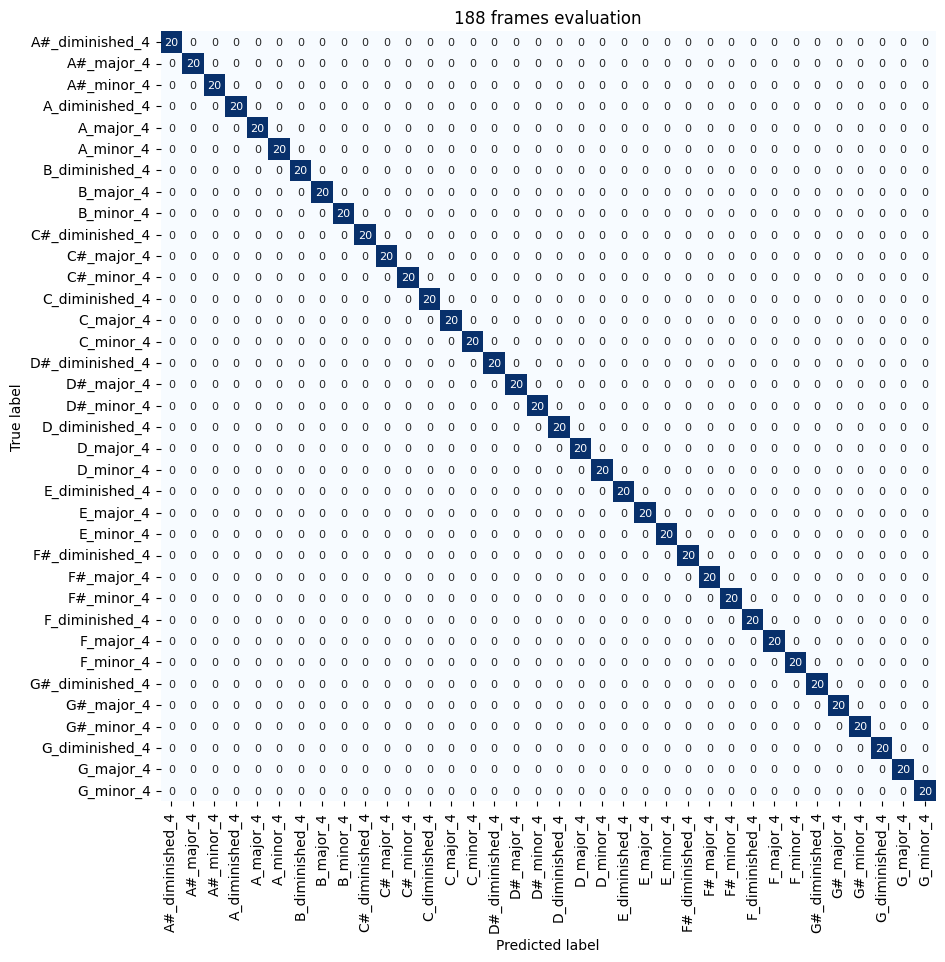

In [5]:
original_results = evaluate_frames()

## 1.5 seconds

,evaluation,input_frames,target_frames,num_samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,140 frames,140,188,720,1.0,1.0,1.0,1.0,1.0,1.0,1.0


,precision,recall,f1-score,support
A#_diminished_4,1.0,1.0,1.0,20.0
A#_major_4,1.0,1.0,1.0,20.0
A#_minor_4,1.0,1.0,1.0,20.0
A_diminished_4,1.0,1.0,1.0,20.0
A_major_4,1.0,1.0,1.0,20.0
A_minor_4,1.0,1.0,1.0,20.0
B_diminished_4,1.0,1.0,1.0,20.0
B_major_4,1.0,1.0,1.0,20.0
B_minor_4,1.0,1.0,1.0,20.0
C#_diminished_4,1.0,1.0,1.0,20.0


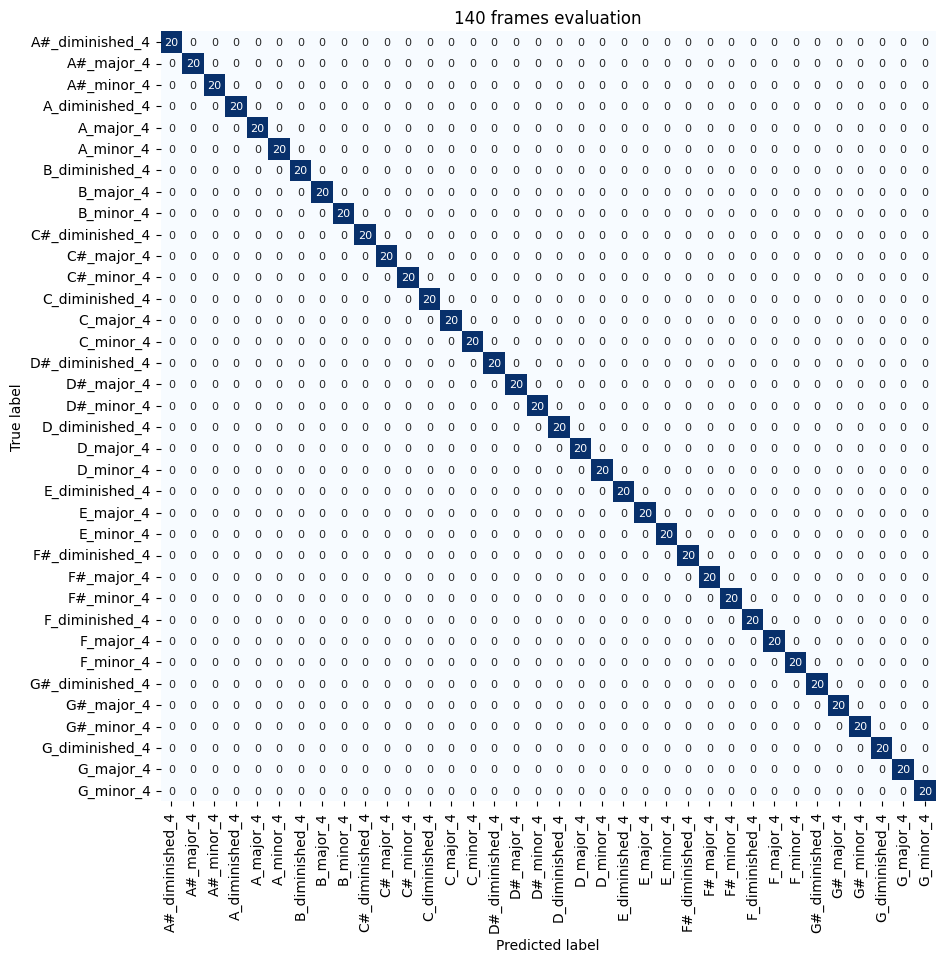

In [6]:
results_150 = evaluate_frames(seconds_to_frames(1.5))

## 1 second

,evaluation,input_frames,target_frames,num_samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,93 frames,93,188,720,0.9972,0.9974,0.9972,0.9972,0.9974,0.9972,0.9972


,precision,recall,f1-score,support
A#_diminished_4,1.0000,1.0000,1.0000,20.0000
A#_major_4,1.0000,1.0000,1.0000,20.0000
A#_minor_4,1.0000,1.0000,1.0000,20.0000
A_diminished_4,1.0000,1.0000,1.0000,20.0000
A_major_4,1.0000,1.0000,1.0000,20.0000
A_minor_4,1.0000,1.0000,1.0000,20.0000
B_diminished_4,1.0000,0.9500,0.9744,20.0000
B_major_4,1.0000,1.0000,1.0000,20.0000
B_minor_4,1.0000,1.0000,1.0000,20.0000
C#_diminished_4,1.0000,1.0000,1.0000,20.0000


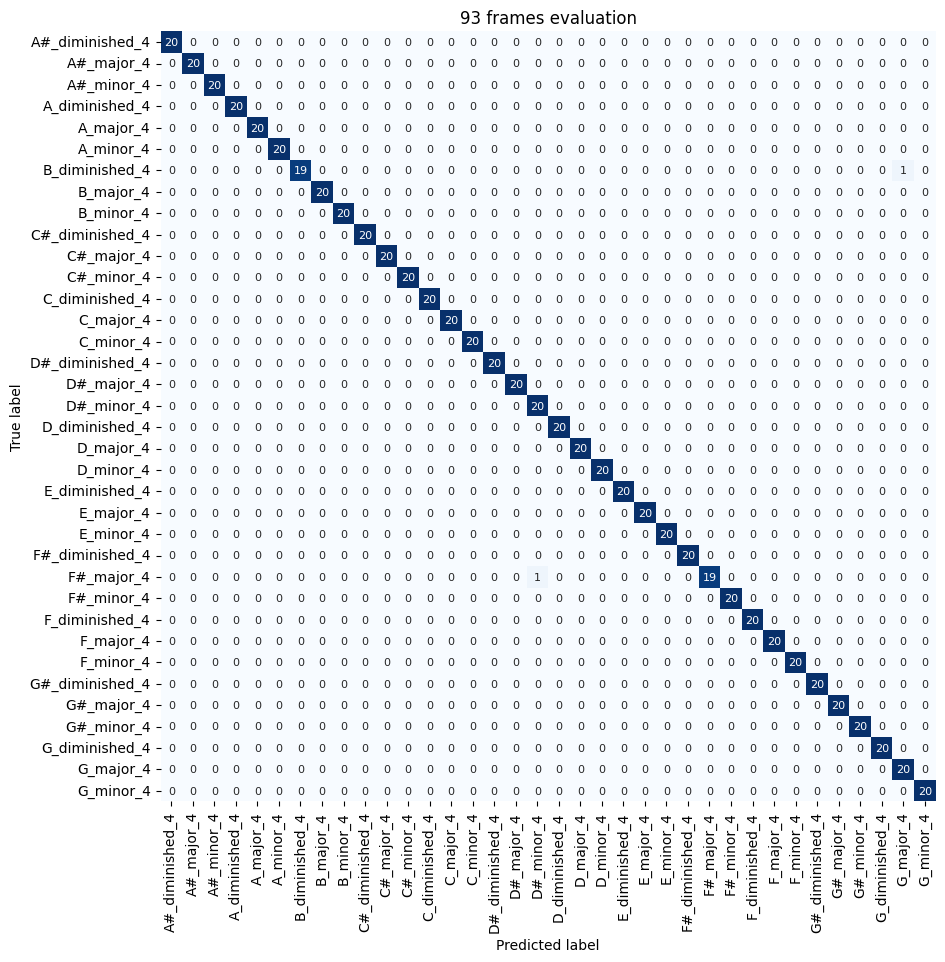

In [7]:
results_100 = evaluate_frames(seconds_to_frames(1))

## 0.5 seconds

,evaluation,input_frames,target_frames,num_samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,46 frames,46,188,720,0.6778,0.7676,0.6778,0.662,0.7676,0.6778,0.662


,precision,recall,f1-score,support
A#_diminished_4,1.0000,0.4000,0.5714,20.0000
A#_major_4,0.6364,0.7000,0.6667,20.0000
A#_minor_4,0.8125,0.6500,0.7222,20.0000
A_diminished_4,1.0000,0.6500,0.7879,20.0000
A_major_4,0.8333,0.5000,0.6250,20.0000
A_minor_4,0.7273,0.8000,0.7619,20.0000
B_diminished_4,0.8182,0.4500,0.5806,20.0000
B_major_4,0.9500,0.9500,0.9500,20.0000
B_minor_4,0.6061,1.0000,0.7547,20.0000
C#_diminished_4,0.9231,0.6000,0.7273,20.0000


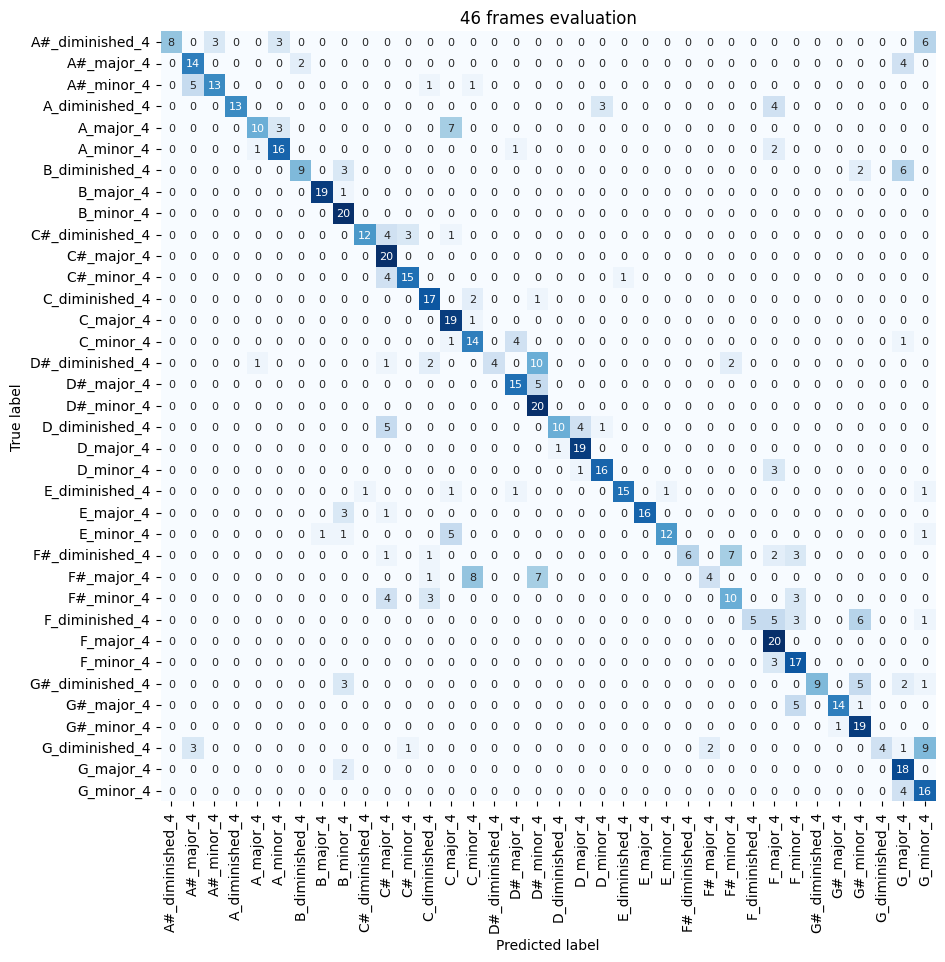

In [8]:
results_50 = evaluate_frames(seconds_to_frames(0.5))

## 0.25 seconds

,evaluation,input_frames,target_frames,num_samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,23 frames,23,188,720,0.2736,0.2835,0.2736,0.2172,0.2835,0.2736,0.2172


,precision,recall,f1-score,support
A#_diminished_4,0.0000,0.0000,0.0000,20.0000
A#_major_4,0.2222,0.1000,0.1379,20.0000
A#_minor_4,0.4545,0.2500,0.3226,20.0000
A_diminished_4,0.5000,0.1500,0.2308,20.0000
A_major_4,0.0000,0.0000,0.0000,20.0000
A_minor_4,0.3846,0.5000,0.4348,20.0000
B_diminished_4,0.5000,0.1000,0.1667,20.0000
B_major_4,0.8889,0.4000,0.5517,20.0000
B_minor_4,0.2727,0.7500,0.4000,20.0000
C#_diminished_4,0.2000,0.1000,0.1333,20.0000


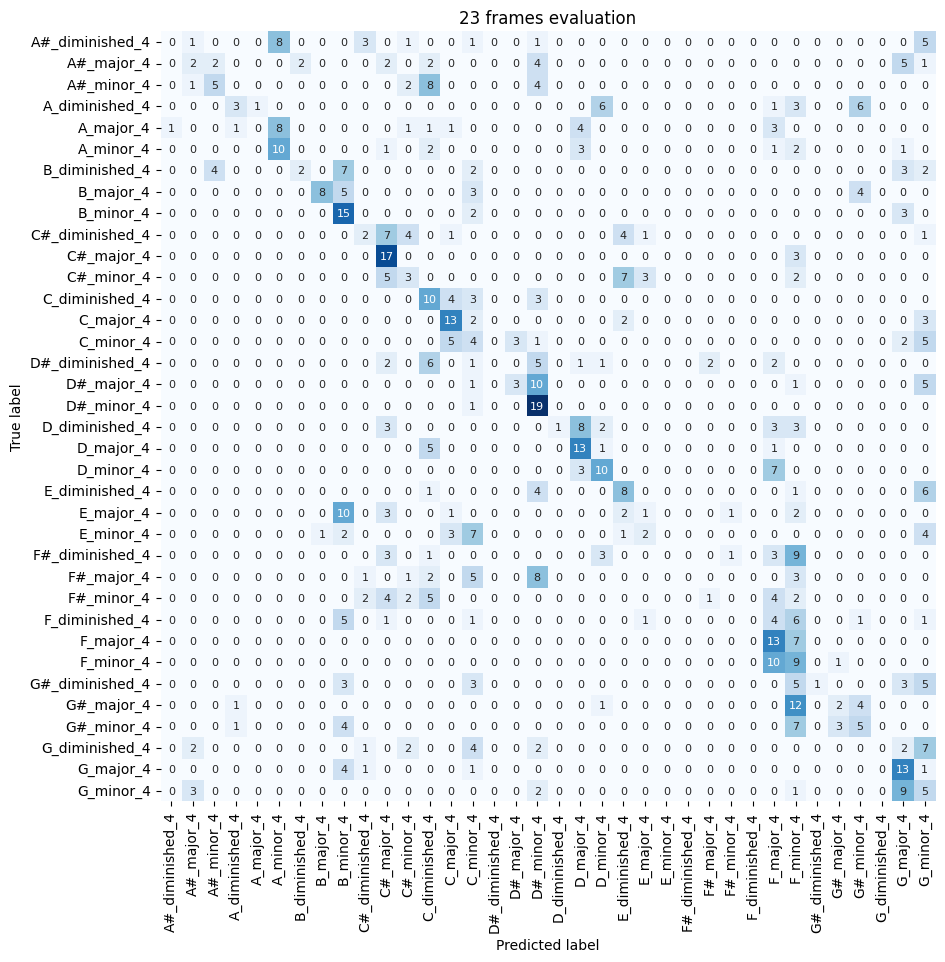

In [9]:
results_25 = evaluate_frames(seconds_to_frames(0.25))

# Results

In [10]:
from IPython.display import display

results_map = {
    "Original features": original_results,
    "First 150 frames": results_150,
    "First 100 frames": results_100,
    "First 50 frames": results_50,
    "First 25 frames": results_25,
}

evaluation_summary_df = pd.concat(
    [
        result["summary"]
        for result in results_map.values()
    ],
    ignore_index=True,
)

evaluation_summary_table = evaluation_summary_df[[
    "evaluation",
    "input_frames",
    "target_frames",
    "num_samples",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
]]

chord_accuracy_frames = []
for evaluation_name, result in results_map.items():
    report_df = result["report"]
    chord_rows = report_df.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore").copy()
    chord_rows = chord_rows[["precision", "recall", "f1-score", "support"]]
    chord_rows.columns = pd.MultiIndex.from_product([[evaluation_name], chord_rows.columns])
    chord_accuracy_frames.append(chord_rows)

chord_accuracy_table = pd.concat(chord_accuracy_frames, axis=1)
chord_accuracy_table.index.name = "chord"

chord_average_accuracy_table = pd.DataFrame({
    "average_accuracy": chord_accuracy_table.xs("recall", axis=1, level=1).mean(axis=1),
    "std_accuracy": chord_accuracy_table.xs("recall", axis=1, level=1).std(axis=1),
    "best_accuracy": chord_accuracy_table.xs("recall", axis=1, level=1).max(axis=1),
    "worst_accuracy": chord_accuracy_table.xs("recall", axis=1, level=1).min(axis=1),
    "average_precision": chord_accuracy_table.xs("precision", axis=1, level=1).mean(axis=1),
    "std_precision": chord_accuracy_table.xs("precision", axis=1, level=1).std(axis=1),
    "best_precision": chord_accuracy_table.xs("precision", axis=1, level=1).max(axis=1),
    "worst_precision": chord_accuracy_table.xs("precision", axis=1, level=1).min(axis=1),
    "sample_count": chord_accuracy_table.xs("support", axis=1, level=1).sum(axis=1).astype(int),
})

comparison_table = evaluation_summary_table.copy()
comparison_table["input_frames"] = comparison_table["input_frames"].astype(int)
comparison_table["target_frames"] = comparison_table["target_frames"].astype(int)

print("Evaluation summary")
display(comparison_table.round(6))

print("Chord accuracy by evaluation")
display(chord_accuracy_table.round(6))

print("Chord average accuracy summary")
display(chord_average_accuracy_table.round(6))

Evaluation summary


,evaluation,input_frames,target_frames,num_samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,188 frames,188,188,720,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,140 frames,140,188,720,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,93 frames,93,188,720,0.997222,0.997354,0.997222,0.997220,0.997354,0.997222,0.997220
3,46 frames,46,188,720,0.677778,0.767631,0.677778,0.662006,0.767631,0.677778,0.662006
4,23 frames,23,188,720,0.273611,0.283493,0.273611,0.217198,0.283493,0.273611,0.217198


Chord accuracy by evaluation


Original features                         First 150 frames  \
                        precision recall f1-score support        precision   
chord                                                                        
A#_diminished_4               1.0    1.0      1.0    20.0              1.0   
A#_major_4                    1.0    1.0      1.0    20.0              1.0   
A#_minor_4                    1.0    1.0      1.0    20.0              1.0   
A_diminished_4                1.0    1.0      1.0    20.0              1.0   
A_major_4                     1.0    1.0      1.0    20.0              1.0   
A_minor_4                     1.0    1.0      1.0    20.0              1.0   
B_diminished_4                1.0    1.0      1.0    20.0              1.0   
B_major_4                     1.0    1.0      1.0    20.0              1.0   
B_minor_4                     1.0    1.0      1.0    20.0              1.0   
C#_diminished_4               1.0    1.0      1.0    20.0              1.0   
C#_major_4                    1.0    1.0      1.0    20.0              1.0   
C#_minor_4                    1.0    1.0      1.0    20.0              1.0   
C_diminished_4                1.0    1.0      1.0    20.0              1.0   
C_major_4                     1.0    1.0      1.0    20.0              1.0   
C_minor_4                     1.0    1.0      1.0    20.0              1.0   
D#_diminished_4               1.0    1.0      1.0    20.0              1.0   
D#_major_4                    1.0    1.0      1.0    20.0              1.0   
D#_minor_4                    1.0    1.0      1.0    20.0              1.0   
D_diminished_4                1.0    1.0      1.0    20.0              1.0   
D_major_4                     1.0    1.0      1.0    20.0              1.0   
D_minor_4                     1.0    1.0      1.0    20.0              1.0   
E_diminished_4                1.0    1.0      1.0    20.0              1.0   
E_major_4                     1.0    1.0      1.0    20.0              1.0   
E_minor_4                     1.0    1.0      1.0    20.0              1.0   
F#_diminished_4               1.0    1.0      1.0    20.0              1.0   
F#_major_4                    1.0    1.0      1.0    20.0              1.0   
F#_minor_4                    1.0    1.0      1.0    20.0              1.0   
F_diminished_4                1.0    1.0      1.0    20.0              1.0   
F_major_4                     1.0    1.0      1.0    20.0              1.0   
F_minor_4                     1.0    1.0      1.0    20.0              1.0   
G#_diminished_4               1.0    1.0      1.0    20.0              1.0   
G#_major_4                    1.0    1.0      1.0    20.0              1.0   
G#_minor_4                    1.0    1.0      1.0    20.0              1.0   
G_diminished_4                1.0    1.0      1.0    20.0              1.0   
G_major_4                     1.0    1.0      1.0    20.0              1.0   
G_minor_4                     1.0    1.0      1.0    20.0              1.0   

                                        First 100 frames                   \
                recall f1-score support        precision recall  f1-score   
chord                                                                       
A#_diminished_4    1.0      1.0    20.0         1.000000   1.00  1.000000   
A#_major_4         1.0      1.0    20.0         1.000000   1.00  1.000000   
A#_minor_4         1.0      1.0    20.0         1.000000   1.00  1.000000   
A_diminished_4     1.0      1.0    20.0         1.000000   1.00  1.000000   
A_major_4          1.0      1.0    20.0         1.000000   1.00  1.000000   
A_minor_4          1.0      1.0    20.0         1.000000   1.00  1.000000   
B_diminished_4     1.0      1.0    20.0         1.000000   0.95  0.974359   
B_major_4          1.0      1.0    20.0         1.000000   1.00  1.000000   
B_minor_4          1.0      1.0    20.0         1.000000   1.00  1.000000   
C#_diminished_4    1.0      1.0    20.0         1

Chord average accuracy summary


,average_accuracy,std_accuracy,best_accuracy,worst_accuracy,average_precision,std_precision,best_precision,worst_precision,sample_count
chord,,,,,,,,,
A#_diminished_4,0.68,0.460435,1.0,0.00,0.800000,0.447214,1.0,0.000000,100
A#_major_4,0.76,0.391152,1.0,0.10,0.771717,0.345183,1.0,0.222222,100
A#_minor_4,0.78,0.332791,1.0,0.25,0.853409,0.237293,1.0,0.454545,100
A_diminished_4,0.76,0.373162,1.0,0.15,0.900000,0.223607,1.0,0.500000,100
A_major_4,0.70,0.447214,1.0,0.00,0.766667,0.434613,1.0,0.000000,100
A_minor_4,0.86,0.219089,1.0,0.50,0.822378,0.271721,1.0,0.384615,100
B_diminished_4,0.70,0.407738,1.0,0.10,0.863636,0.217992,1.0,0.500000,100
B_major_4,0.87,0.263629,1.0,0.40,0.967778,0.049128,1.0,0.888889,100
B_minor_4,0.95,0.111803,1.0,0.75,0.775758,0.328896,1.0,0.272727,100
